In [30]:
import operator
from typing import TypedDict, Annotated

from IPython.display import display, Image
from langgraph.graph import START, END, StateGraph

In [31]:
class State(TypedDict):
    nlist: Annotated[list[str], operator.add]

In [32]:
def node_a(state: State) -> State:
    print(f"Adding 'A' to {state['nlist']}")
    return {
        "nlist":["A"]
    }


def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['nlist']}")
    return {
        "nlist":["B"]
    }


def node_c(state: State) -> State:
    print(f"Adding 'C' to {state['nlist']}")
    return {
        "nlist":["C"]
    }


def node_bb(state: State) -> State:
    print(f"Adding 'BB' to {state['nlist']}")
    return {
        "nlist":["BB"]
    }


def node_cc(state: State) -> State:
    print(f"Adding 'CC' to {state['nlist']}")
    return {
        "nlist":["CC"]
    }


def node_d(state: State) -> State:
    """Fan-in / sync at d
        When two edges go into the same node (bb → d and cc → d), LangGraph treats that as a join:

        Wait until both bb and cc finish
        Merge their state updates
        Run 'd' once on the combined state
        So 'd' is a synchronization point, not a node that runs per incoming edge."""
    print(f"Adding 'D' to {state['nlist']}")
    return {
        "nlist":["D"]
    }

In [ ]:
def node_a(state: State) -> State:
    print(f"Adding 'A' to {state['nlist']}")
    state["nlist"]=["A"]
    return state


def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['nlist']}")
    state["nlist"]=["B"]
    return state


def node_c(state: State) -> State:
    print(f"Adding 'C' to {state['nlist']}")
    state["nlist"]=["C"]
    return state


def node_bb(state: State) -> State:
    print(f"Adding 'BB' to {state['nlist']}")
    state["nlist"]=["BB"]
    return state


def node_cc(state: State) -> State:
    print(f"Adding 'CC' to {state['nlist']}")
    state["nlist"]=["CC"]
    return state


def node_d(state: State) -> State:
    """Fan-in / sync at d
        When two edges go into the same node (bb → d and cc → d), LangGraph treats that as a join:

        Wait until both bb and cc finish
        Merge their state updates
        Run 'd' once on the combined state
        So 'd' is a synchronization point, not a node that runs per incoming edge."""
    print(f"Adding 'D' to {state['nlist']}")
    state["nlist"]=["D"]
    return state

In [ ]:
def node_a(state: State) -> State:
    print(f"Adding 'A' to {state['nlist']}")
    return State(nlist=["A"])


def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['nlist']}")
    return State(nlist=["B"])


def node_c(state: State) -> State:
    print(f"Adding 'C' to {state['nlist']}")
    return State(nlist=["C"])


def node_bb(state: State) -> State:
    print(f"Adding 'BB' to {state['nlist']}")
    return State(nlist=["BB"])


def node_cc(state: State) -> State:
    print(f"Adding 'CC' to {state['nlist']}")
    return State(nlist=["CC"])


def node_d(state: State) -> State:
    """Fan-in / sync at d
        When two edges go into the same node (bb → d and cc → d), LangGraph treats that as a join:

        Wait until both bb and cc finish
        Merge their state updates
        Run 'd' once on the combined state
        So 'd' is a synchronization point, not a node that runs per incoming edge."""
    print(f"Adding 'D' to {state['nlist']}")
    return State(nlist=["D"])

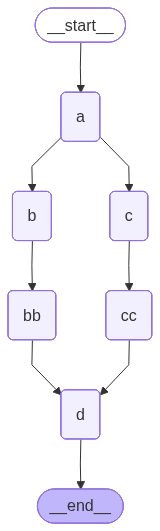

In [33]:
builder = StateGraph(State)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)
builder.add_node("bb", node_bb)
builder.add_node("cc", node_cc)
builder.add_node("d", node_d)

# Add edges
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "bb")
builder.add_edge("c", "cc")
builder.add_edge("bb", "d")
builder.add_edge("cc", "d")
builder.add_edge("d", END)

# Compile and display
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
initial_state = State(
    nlist = ["Initial String:"]
)
graph.invoke(initial_state)

Adding 'A' to ['Initial String:']
Adding 'B' to ['Initial String:', 'A']
Adding 'C' to ['Initial String:', 'A']
Adding 'CC' to ['Initial String:', 'A', 'B', 'C']
Adding 'BB' to ['Initial String:', 'A', 'B', 'C']
Adding 'D' to ['Initial String:', 'A', 'B', 'C', 'BB', 'CC']


{'nlist': ['Initial String:', 'A', 'B', 'C', 'BB', 'CC', 'D']}